## Building a basic chatbot with langgraph (graph api)

In [146]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import START , END , StateGraph
from langgraph.graph.message import add_messages


In [147]:
class State(TypedDict):
    messages: Annotated[list, add_messages] ## here add messaages is a reducer which will append the messages to the list rather than overwriting them.


graph_builder = StateGraph(State)

In [148]:
graph_builder

In [149]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [150]:
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model = "gemini-2.5-flash"
)

In [151]:
llm

ChatGoogleGenerativeAI(output_version=None, profile={'name': 'Gemini 2.5 Flash', 'release_date': '2025-03-20', 'last_updated': '2025-06-05', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-2.5-flash', client=<google.genai.client.Client object at 0x000001B4A5F36FD0>, default_metadata=(), model_kwargs={})

In [152]:
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

In [153]:
graph_builder = StateGraph(State)
graph_builder.add_node("llmchatbot",chatbot)

graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot" , END)

In [154]:
graph = graph_builder.compile()

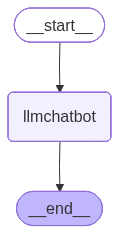

In [155]:
graph

In [156]:
response = graph.invoke({"messages": ["what is the capital of India?"]})

In [157]:
response["messages"][-1].content

'The capital of India is **New Delhi**.'

In [158]:
for event in graph.stream({"messages":"Hi how are you?"}):
    for value in event.values():
        print(value['messages'][-1].content)

Hello! As an AI, I don't experience feelings or have a physical state, but I'm functioning perfectly and ready to help. Thanks for asking!

How about you? I hope you're having a good day!


## Chatbot with Tool

In [159]:
from langchain_tavily import TavilySearch

tool =  TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph',
   'title': 'What is LangGraph - GeeksforGeeks',
   'content': 'LangGraph is an open-source framework built by LangChain that streamlines the creation and management of AI agent workflows. At its core, LangGraph combines large language models (LLMs) with graph-based architectures allowing developers to map, organize and optimize how AI agents interact and make decisions. By treating workflows as interconnected nodes and edges, LangGraph offers a scalable, transparent and developer-friendly way to design advanced AI systems ranging from simple chatbots to multi-agent system. The diagram below shows how LangGraph structures its agent-based workflow using distinct tools and stages. By designing workflows, users combine multiple nodes into powerful, dynamic AI processes. * ****langgraph:**** Framework for build

In [160]:
## custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b
    Args:
        a (int) : first int
        b (int) : second int

    Returns:
        int : output int    
    """
    return a*b

In [161]:
tools = [tool,multiply]

In [162]:
llm_with_tool = llm.bind_tools(tools)

In [163]:
llm_with_tool

_ChatModelBinding(bound=ChatGoogleGenerativeAI(output_version=None, profile={'name': 'Gemini 2.5 Flash', 'release_date': '2025-03-20', 'last_updated': '2025-06-05', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-2.5-flash', client=<google.genai.client.Client object at 0x000001B4A5F36FD0>, default_metadata=(), model_kwargs={}), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful 

In [164]:
## Stategraph
from langgraph.graph import StateGraph , START , END
from langgraph.prebuilt import ToolNode , tools_condition

## Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm" , tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## edges
builder.add_edge(START , "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message(result) from assistant is a tool call -> tools_condition routes to tools
    # if the latest message(result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile graph
graph = builder.compile()

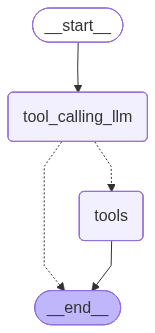

In [165]:
graph

In [166]:
response = graph.invoke({"messages": ["what is the recent ai news?"]})

In [167]:
response['messages'][-1].content

'{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://indianacapitalchronicle.com/2026/05/20/how-indy-newsrooms-are-using-ai/", "title": "How Indy newsrooms are using AI - Indiana Capital Chronicle", "score": 0.9988305, "published_date": "Wed, 20 May 2026 08:45:02 GMT", "content": "# How Indy newsrooms are using AI. ## What to look for as a savvy news consumer. Newsrooms across Indianapolis are in the early stages of experimenting with artificial intelligence. News consumers have real fears about how artificial intelligence is used in journalism, with good reason. Indianapolis newsrooms are in the early stages of experimenting with AI. That’s why I thought it would be a good idea to look at how local newsrooms are using this technology and what ethical guidelines consumers should expect from their news providers. Of all the Indianapolis news outlets, Black Indy Live has been the most experimental in its use of AI. Most of the loca

In [168]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the recent ai news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (e47f8e6b-2f16-4540-88a0-880bbbbd39a8)
 Call ID: e47f8e6b-2f16-4540-88a0-880bbbbd39a8
  Args:
    query: AI news
    topic: news
    time_range: week
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://indianacapitalchronicle.com/2026/05/20/how-indy-newsrooms-are-using-ai/", "title": "How Indy newsrooms are using AI - Indiana Capital Chronicle", "score": 0.9988305, "published_date": "Wed, 20 May 2026 08:45:02 GMT", "content": "# How Indy newsrooms are using AI. ## What to look for as a savvy news consumer. Newsrooms across Indianapolis are in the early stages of experimenting with artificial intelligence. News cons

In [170]:
response = graph.invoke({"messages": [" give me the recent ai news and then what is 15 multiplied by 15 ?"]})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

 give me the recent ai news and then what is 15 multiplied by 15 ?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (31b0592a-0c29-45e9-aeee-375666fed088)
 Call ID: 31b0592a-0c29-45e9-aeee-375666fed088
  Args:
    topic: news
    query: recent AI news
    time_range: week
  multiply (35e9fd94-a9f5-43bd-a12a-d8821d0b146c)
 Call ID: 35e9fd94-a9f5-43bd-a12a-d8821d0b146c
  Args:
    a: 15
    b: 15
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.washingtonpost.com/wp-intelligence/ai-tech-brief/2026/05/19/ai-tech-brief-ai-influence-machine/", "title": "AI & Tech Brief: The AI Influence Machine - The Washington Post", "score": 0.80069196, "published_date": "Tue, 19 May 2026 18:56:2

## ReAct agent architecture

In [171]:
## Stategraph
from langgraph.graph import StateGraph , START , END
from langgraph.prebuilt import ToolNode , tools_condition

## Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm" , tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## edges
builder.add_edge(START , "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message(result) from assistant is a tool call -> tools_condition routes to tools
    # if the latest message(result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile graph
graph = builder.compile()

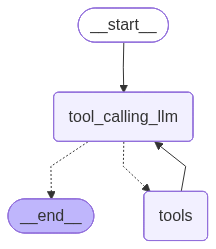

In [172]:
graph

In [ ]:
from langchain_core.messages import HumanMessage

response = graph.invoke({"messages": [HumanMessage(content="give me the recent ai news and then multiply 15 by 15?")]})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

give me the recent ai news and then multiply 15 by 15?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (b71e993c-6498-4d8f-b6a1-b8e784265c42)
 Call ID: b71e993c-6498-4d8f-b6a1-b8e784265c42
  Args:
    query: recent AI news
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.washingtonpost.com/wp-intelligence/ai-tech-brief/2026/05/19/ai-tech-brief-ai-influence-machine/", "title": "AI & Tech Brief: The AI Influence Machine - The Washington Post", "score": 0.80069196, "published_date": "Tue, 19 May 2026 18:56:21 GMT", "content": "AI & Tech Brief from WP Intelligence. # AI & Tech Brief: The AI Influence Machine. Plus, Scale AI launches a new seve

## Adding memory to agentic graph

In [176]:
from langchain_core.messages import HumanMessage

response = graph.invoke({"messages": [HumanMessage(content="Hey my name is srijan")]})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hey my name is srijan
================================== Ai Message ==================================

Hello Srijan, how can I help you?


In [177]:
from langchain_core.messages import HumanMessage

response = graph.invoke({"messages": [HumanMessage(content="what is my name ?")]})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is my name ?
================================== Ai Message ==================================

I do not know your name. I am a large language model, able to communicate in response to a wide range of prompts and questions, but I have no memory of past conversations. Please tell me your name.


In [178]:
## Stategraph
from langgraph.graph import StateGraph , START , END
from langgraph.prebuilt import ToolNode , tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm" , tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## edges
builder.add_edge(START , "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message(result) from assistant is a tool call -> tools_condition routes to tools
    # if the latest message(result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile graph
graph = builder.compile(checkpointer=memory)

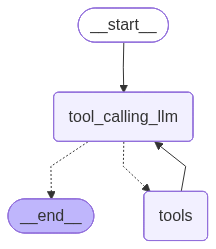

In [179]:
graph

In [183]:
config = {"configurable":{"thread_id":"1"}}

response = graph.invoke({"messages":"Hi my name is srijan !"},config=config)

response

{'messages': [HumanMessage(content='Hi my name is srijan !', additional_kwargs={}, response_metadata={}, id='c8dd381f-980d-4314-90fc-ab4758f1cdb6'),
  AIMessage(content='Hello Srijan! How can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e5948-f21f-7740-aa59-9dbaf55da622-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1514, 'output_tokens': 12, 'total_tokens': 1526, 'input_token_details': {'cache_read': 0}})]}

In [184]:
response = graph.invoke({"messages":"what is my name ?"},config=config)

response

{'messages': [HumanMessage(content='Hi my name is srijan !', additional_kwargs={}, response_metadata={}, id='c8dd381f-980d-4314-90fc-ab4758f1cdb6'),
  AIMessage(content='Hello Srijan! How can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e5948-f21f-7740-aa59-9dbaf55da622-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1514, 'output_tokens': 12, 'total_tokens': 1526, 'input_token_details': {'cache_read': 0}}),
  HumanMessage(content='what is my name ?', additional_kwargs={}, response_metadata={}, id='63db7e34-2f34-4d4a-bb5b-f154b617c7ad'),
  AIMessage(content=[{'type': 'text', 'text': 'Your name is Srijan.', 'extras': {'signature': 'CrUBAQw51sfn/1qw3iEBEH968CXXcvc1Sobq7h6zynD33zf7w2Ju4l/oEIczIJsWwS75gHMDKIzwb4zR0PK7TYzTJbZQ6Z88oLOqaOtKaUZuwRmJeweFjJl5w2MibSqHoZfpt30NaoA1zlkqCduqnliCmunanDNn9PYx8GaDsg/E/G83JzYoZeXH4/uY

In [185]:
response['messages'][-1].content

[{'type': 'text',
  'text': 'Your name is Srijan.',
  'extras': {'signature': 'CrUBAQw51sfn/1qw3iEBEH968CXXcvc1Sobq7h6zynD33zf7w2Ju4l/oEIczIJsWwS75gHMDKIzwb4zR0PK7TYzTJbZQ6Z88oLOqaOtKaUZuwRmJeweFjJl5w2MibSqHoZfpt30NaoA1zlkqCduqnliCmunanDNn9PYx8GaDsg/E/G83JzYoZeXH4/uYkMOy/1rKEqeZQa7U0jsdh5n4F9lfKCtyOZuAZ61p66RN3PQU6M4WzTE2dg=='}}]

# Streaming

Methods: `.stream()` and `astream()`

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state:

- **values**: This streams the full state of the graph after each node is called.
- **updates**: This streams updates to the state of the graph after each node is called.

In [197]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [198]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

In [199]:
graph = StateGraph(State)

graph.add_node("superbot",superbot)

graph.add_edge(START , "superbot")
graph.add_edge("superbot" , END)

graph_builder = graph.compile(checkpointer=memory)



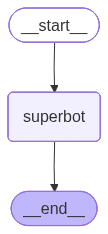

In [200]:
graph_builder

In [201]:
config = {"configurable":{"thread_id":"1"}}

graph_builder.invoke({"messages":"Hi my name is srijan and i like cricket"},config)

{'messages': [HumanMessage(content='Hi my name is srijan and i like cricket', additional_kwargs={}, response_metadata={}, id='13be8c52-8351-47ae-a296-76042ae78bef'),
  AIMessage(content='<think>\nOkay, the user is Srijan and mentioned they like cricket. Let me start by acknowledging their name and interest. I should respond in a friendly and encouraging way.\n\nFirst, a greeting: "Hi Srijan!" to make it personal. Then express enthusiasm about cricket since it\'s their interest. Maybe ask how they got into the sport to engage them further. \n\nI should also offer to share more about cricket if they want, like tips or info about players. Keep the tone open and inviting. Avoid using any technical jargon unless they ask. Make sure the response is concise and not too long. Check for grammar and flow. Alright, that should cover it.\n</think>\n\nHi Srijan! Nice to meet you. Cricket is an amazing sport—so exciting to watch and play! 🏏 How did you get into it? Do you follow a particular team or

In [202]:
config = {"configurable":{"thread_id":"3"}}

for chunk in graph_builder.stream({"messages":"Hi my name is srijan and i like cricket"},config,stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content="<think>\nOkay, the user introduced themselves as Srijan and mentioned they like cricket. I need to respond in a friendly and engaging way. Let me start by welcoming them and acknowledging their name. Then, since they mentioned liking cricket, I should ask a follow-up question to encourage conversation. Maybe ask about their favorite team or player to keep the discussion going. I should keep the tone positive and approachable. Let me make sure the response is concise but not too short. Alright, that should work.\n</think>\n\nHi Srijan! Nice to meet you! 🏏 I love cricket too—do you have a favorite team or player? Let me know if you'd like to chat about the sport or anything else! 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 150, 'prompt_tokens': 19, 'total_tokens': 169, 'completion_time': 0.310566236, 'completion_tokens_details': None, 'prompt_time': 0.000975981, 'prompt_tokens_details': None, 'queue_time'

In [203]:
for chunk in graph_builder.stream({"messages":"Hi my name is srijan and i like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi my name is srijan and i like cricket', additional_kwargs={}, response_metadata={}, id='547e86b2-f7c7-4f75-8eee-b8e913fbd28c'), AIMessage(content="<think>\nOkay, the user introduced themselves as Srijan and mentioned they like cricket. I need to respond in a friendly and engaging way. Let me start by welcoming them and acknowledging their name. Then, since they mentioned liking cricket, I should ask a follow-up question to encourage conversation. Maybe ask about their favorite team or player to keep the discussion going. I should keep the tone positive and approachable. Let me make sure the response is concise but not too short. Alright, that should work.\n</think>\n\nHi Srijan! Nice to meet you! 🏏 I love cricket too—do you have a favorite team or player? Let me know if you'd like to chat about the sport or anything else! 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 150, 'prompt_tokens': 19, 'total_tokens': 169,

In [204]:
config = {"configurable":{"thread_id":"5"}}

async for chunk in graph_builder.astream_events({"messages":"Hi my name is srijan and i like cricket"},config,version="v2"):
    print(chunk)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi my name is srijan and i like cricket'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019e5a05-0606-74f1-8d50-b1557e40df2b', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi my name is srijan and i like cricket', additional_kwargs={}, response_metadata={}, id='7a1f26c5-454d-41d3-8833-a17b55e324ee')]}}, 'name': 'superbot', 'tags': ['graph:step:1'], 'run_id': '019e5a05-060b-7f80-98b2-6b87f22b0964', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'superbot', 'langgraph_triggers': ('branch:to:superbot',), 'langgraph_path': ('__pregel_pull', 'superbot'), 'langgraph_checkpoint_ns': 'superbot:a589d4da-7c5a-a7c6-1f1a-cea801c467f5'}, 'parent_ids': ['019e5a05-0606-74f1-8d50-b1557e40df2b']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(